In [4]:
import least_entropy_antialiasing_typed as le
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import os
import numpy as np
from testing import test 

In [5]:
def procesar_archivos(carpeta, tipo, x_parts=8, y_parts=8, p0=0.4, p1=500, p_num=10000, plot_individual=False, plot_s=False, plot_p=False):
    """   
    Parámetros:
    -----------
    carpeta : str
        Ruta a la carpeta con los archivos .dat
    N : int
        Número de archivos a procesar
    p0, p1, np : parámetros para find_best_period
    plot_individual : bool
        Si True, muestra la curva de luz de cada estrella
    """
    
    # Obtener lista de archivos .dat y ordenarlos numéricamente
    #archivos = [f for f in os.listdir(carpeta) if f.endswith('.dat')]
    archivos = [f for f in os.listdir(carpeta)]
    
    # Limitar a los primeros N
    #archivos = archivos[:N]
    
    print(f"Procesando {len(archivos)} archivos de {carpeta}")
    
    # Lista para guardar resultados
    resultados = []
    
    for archivo in tqdm(archivos, desc="Procesando estrellas"):
        try:
            # Cargar datos
            ruta_completa = os.path.join(carpeta, archivo)
            test_data = pd.read_csv(ruta_completa, sep=" ", lineterminator="\n", 
                                    names=("t", "u", "inc_u"))
            
            #Aislar nombre de la estrella
            nombre = archivo.split(".")[0]
            
            # Encontrar período
            best_period, min_entropy, final_phases, second_phases = le.find_best_period(
                test_data, 
                star_type=tipo,
                plot_entropies=plot_s,
                p0=p0,
                p1=p1,
                p_num=p_num,
                t_parts=x_parts,
                u_parts=y_parts,
                plot_periods=plot_p,
                name=nombre
            )

            #Calcular errores
            period_teo, abs_err, rel_err = test(nombre, best_period)
            
            # Guardar resultado
            resultados.append({
                'archivo': archivo,
                'id': nombre,
                'best_period': best_period,
                'real_period': period_teo,
                'abs_error': abs_err,
                'rel_error': rel_err,
                'min_entropy': min_entropy,
                'n_puntos': len(test_data)
            })
            
            # Plot individual si se solicita
            if plot_individual:
                plt.figure(figsize=(8, 4))
                plt.scatter(final_phases, test_data["u"], s=5, alpha=0.7)
                plt.scatter(second_phases, test_data["u"], s=5, alpha=0.7)
                plt.xlabel('Fase')
                plt.ylabel('Magnitud')
                plt.title(f'Estrella {nombre} - Período = {best_period:.4f} días')
                plt.gca().invert_yaxis()  # Para magnitudes
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                plt.show()
                
        except Exception as e:
            print(f"Error procesando {archivo}: {e}")
            resultados.append({
                'archivo': archivo,
                'id': nombre,
                'best_period': None,
                'real_period': None,
                'abs_error': None,
                'rel_err': None,
                'min_entropy': None,
                'n_puntos': None,
                'error': str(e)
            })
    
    # Crear DataFrame con resultados
    df_resultados = pd.DataFrame(resultados)
    
    # Mostrar resumen
    print("\n" + "="*60)
    print("RESUMEN DE RESULTADOS")
    print("="*60)
    for idx, row in df_resultados.iterrows():
        if row['best_period'] is not None:
            print(f"{row['id']}: Período hallado = {row['best_period']:.6f} días, "
                  f"Período documentado = {row['real_period']:.6f} días, "
                  f"Entropía = {row['min_entropy']:.4f}, Puntos = {row['n_puntos']}, "
                  f"Error absoluto = {row["abs_error"]:.4f}, Error relativo: {row["rel_error"]:.4f}")
        else:
            print(f"{row['id']}: ERROR - {row.get('error', 'Desconocido')}")
    
    return df_resultados

Procesando 6 archivos de data/rr_lyrae


9772it [00:17, 554.14it/s]|          | 0/6 [00:00<?, ?it/s]


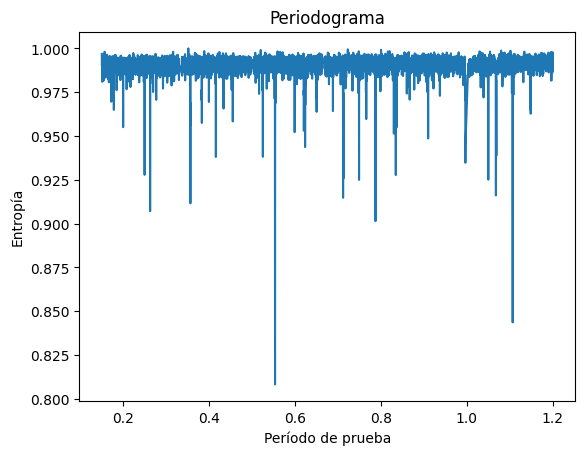

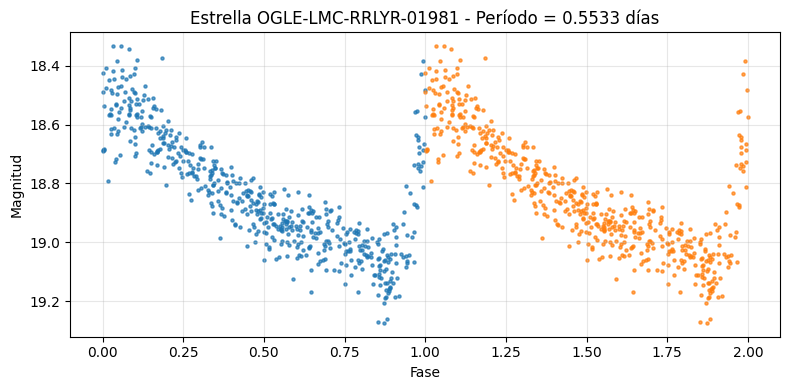

9772it [00:19, 510.38it/s]|█▋        | 1/6 [00:18<01:31, 18.31s/it]


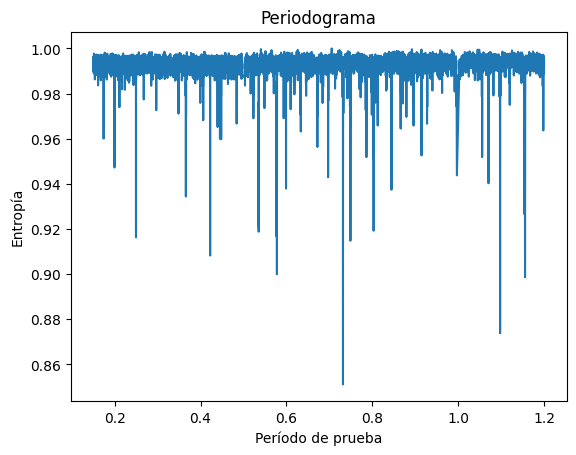

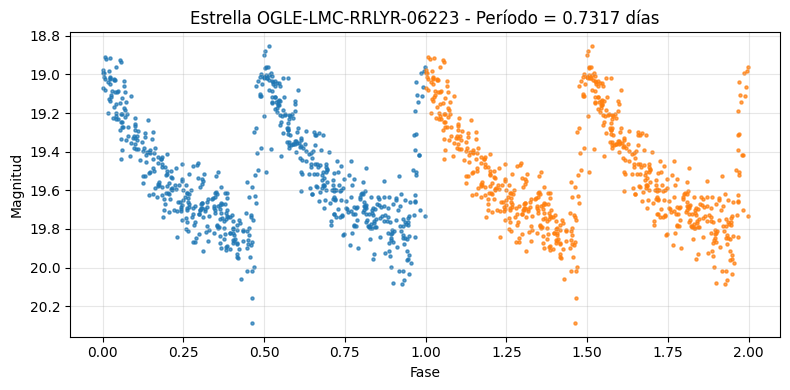

9772it [00:19, 506.19it/s]|███▎      | 2/6 [00:38<01:16, 19.19s/it]


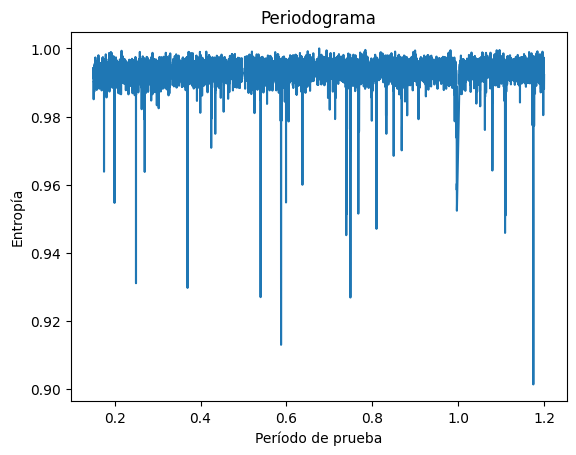

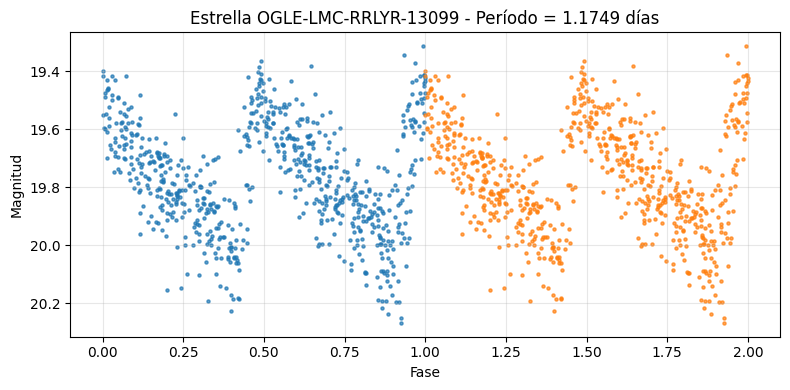

9772it [00:18, 520.36it/s]|█████     | 3/6 [00:58<00:58, 19.52s/it]


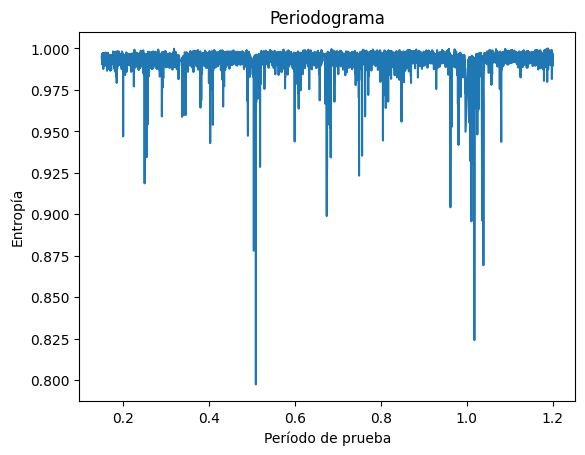

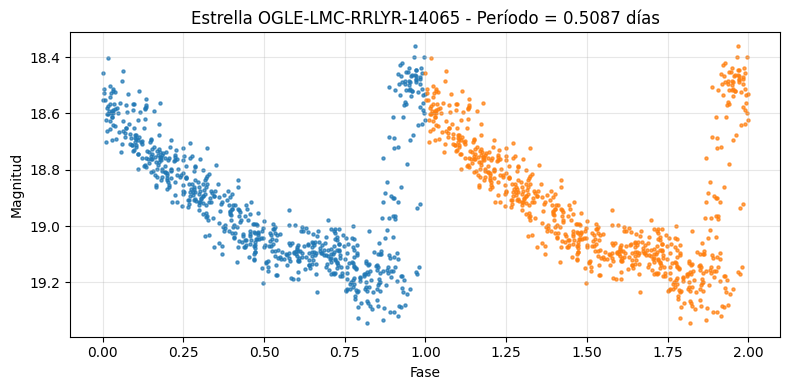

9772it [00:19, 502.22it/s]|██████▋   | 4/6 [01:17<00:38, 19.49s/it]


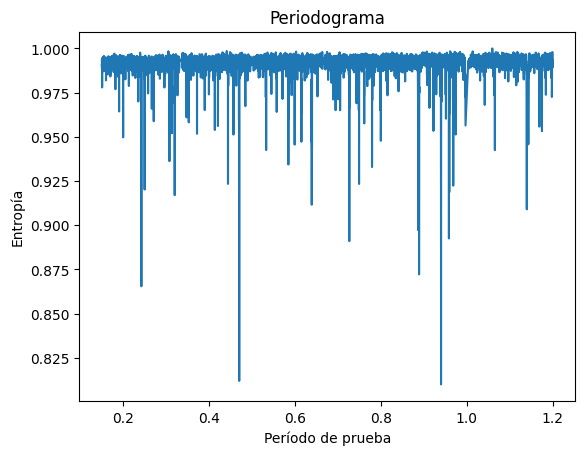

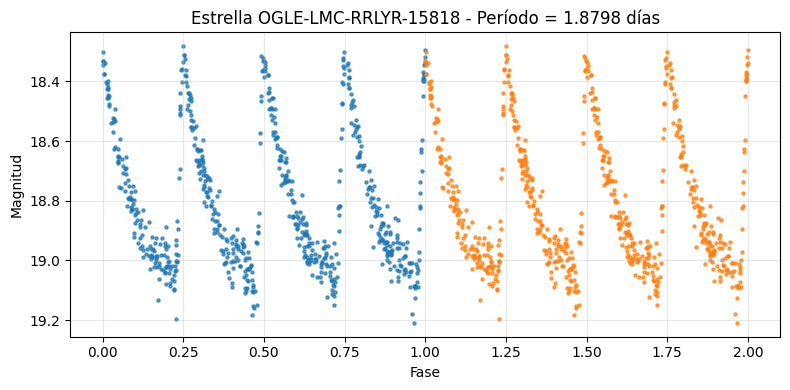

9772it [00:18, 533.73it/s]|████████▎ | 5/6 [01:37<00:19, 19.74s/it]


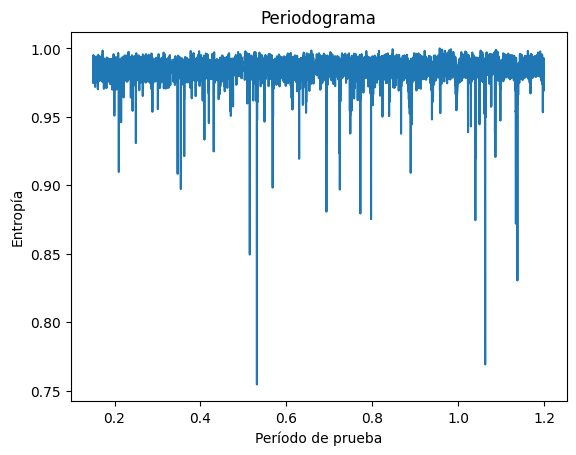

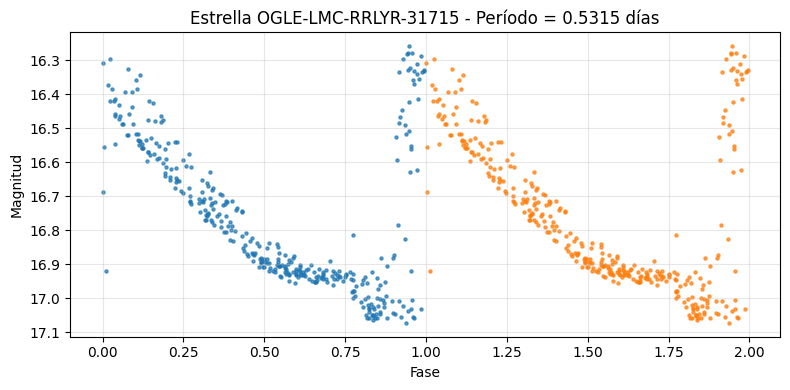

Procesando estrellas: 100%|██████████| 6/6 [01:56<00:00, 19.46s/it]


RESUMEN DE RESULTADOS
OGLE-LMC-RRLYR-01981: Período hallado = 0.553345 días, Período documentado = 0.553360 días, Entropía = 0.8081, Puntos = 552, Error absoluto = 0.0000, Error relativo: 0.0000
OGLE-LMC-RRLYR-06223: Período hallado = 0.731653 días, Período documentado = 0.365834 días, Entropía = 0.8511, Puntos = 661, Error absoluto = 0.3658, Error relativo: 1.0000
OGLE-LMC-RRLYR-13099: Período hallado = 1.174902 días, Período documentado = 0.587430 días, Entropía = 0.9014, Puntos = 714, Error absoluto = 0.5875, Error relativo: 1.0001
OGLE-LMC-RRLYR-14065: Período hallado = 0.508716 días, Período documentado = 0.508740 días, Entropía = 0.7974, Puntos = 704, Error absoluto = 0.0000, Error relativo: 0.0000
OGLE-LMC-RRLYR-15818: Período hallado = 1.879778 días, Período documentado = 0.469950 días, Entropía = 0.8100, Puntos = 695, Error absoluto = 1.4098, Error relativo: 3.0000
OGLE-LMC-RRLYR-31715: Período hallado = 0.531503 días, Período documentado = 0.531520 días, Entropía = 0.7545, P

In [6]:
# RR LYRAE
if __name__ == "__main__":
    resultados = procesar_archivos(
        carpeta="data/rr_lyrae",
        tipo="rrlyrae",
        p0=0.15,
        p1=1.2,
        p_num=10000,  
        plot_individual=True,  # Muestra cada curva de luz
        x_parts=12,
        y_parts=7,
        plot_s=True
    )
    
    # Guardar resultados a CSV
    resultados.to_csv("resultados_periodos_rrlyrae.csv", index=False)
    print(f"\nResultados guardados en 'resultados_periodos.csv'")

Procesando 4 archivos de data/cefeidas


Procesando estrellas:   0%|          | 0/4 [00:00<?, ?it/s]

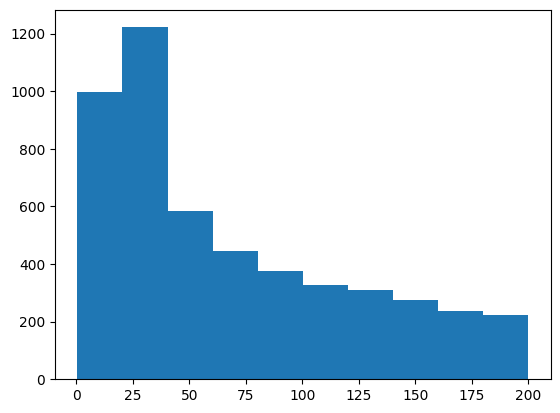

4784it [00:07, 662.15it/s]


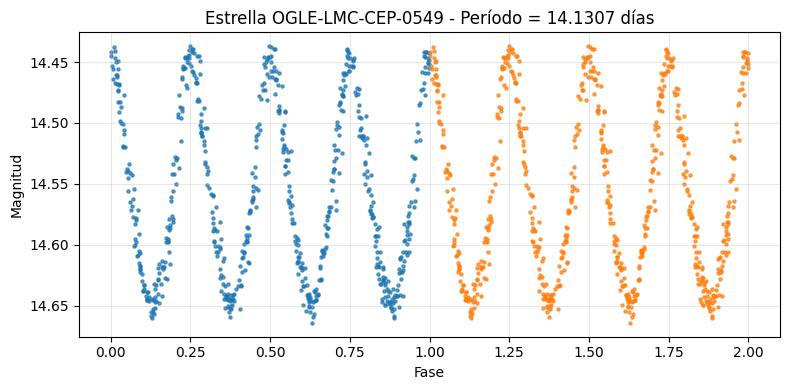

Procesando estrellas:  25%|██▌       | 1/4 [00:07<00:23,  7.71s/it]

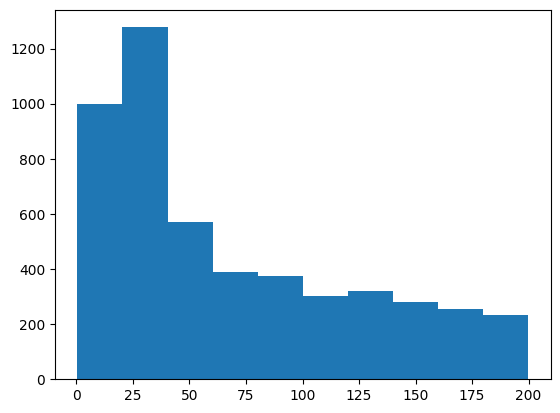

4780it [00:06, 705.46it/s]


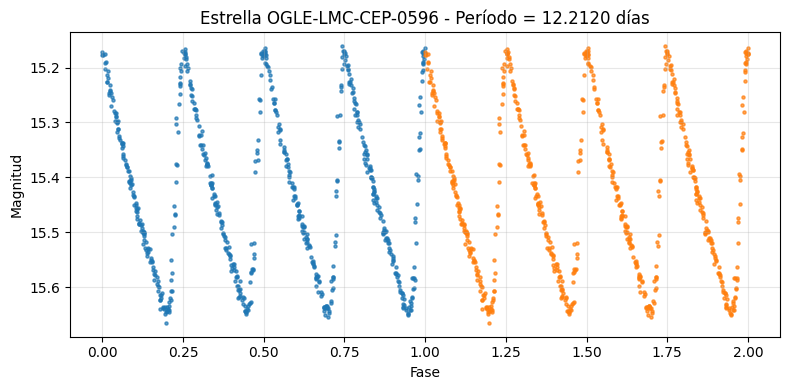

Procesando estrellas:  50%|█████     | 2/4 [00:14<00:14,  7.44s/it]

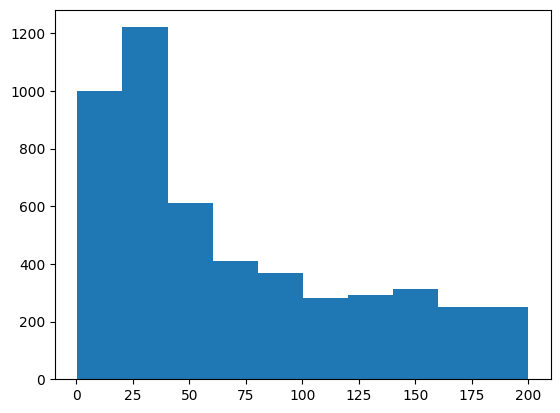

4786it [00:06, 703.27it/s]


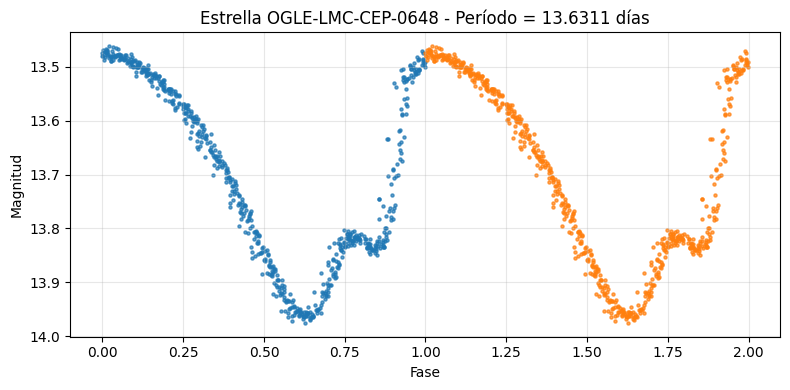

Procesando estrellas:  75%|███████▌  | 3/4 [00:22<00:07,  7.41s/it]

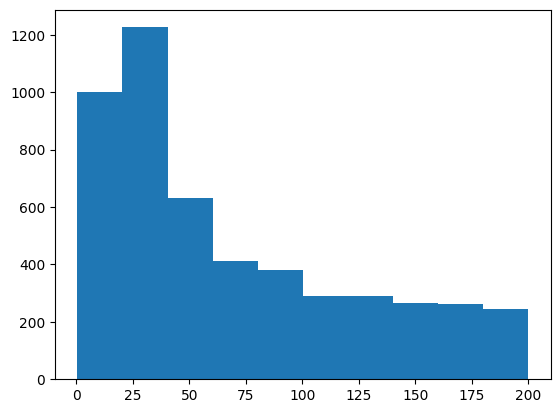

4786it [00:08, 587.50it/s]


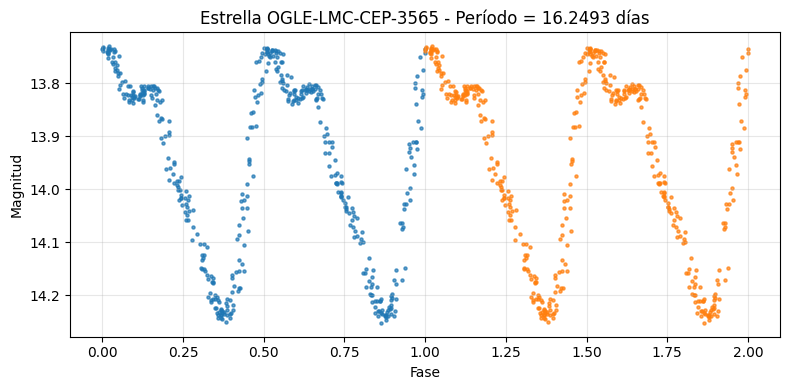

Procesando estrellas: 100%|██████████| 4/4 [00:30<00:00,  7.74s/it]


RESUMEN DE RESULTADOS
OGLE-LMC-CEP-0549: Período hallado = 14.130722 días, Período documentado = 3.533000 días, Entropía = 0.8844, Puntos = 689, Error absoluto = 10.5977, Error relativo: 2.9996
OGLE-LMC-CEP-0596: Período hallado = 12.212019 días, Período documentado = 3.052700 días, Entropía = 0.8656, Puntos = 648, Error absoluto = 9.1593, Error relativo: 3.0004
OGLE-LMC-CEP-0648: Período hallado = 13.631060 días, Período documentado = 13.626000 días, Entropía = 0.7154, Puntos = 669, Error absoluto = 0.0051, Error relativo: 0.0004
OGLE-LMC-CEP-3565: Período hallado = 16.249291 días, Período documentado = 8.128000 días, Entropía = 0.7623, Puntos = 464, Error absoluto = 8.1213, Error relativo: 0.9992

Resultados guardados en 'resultados_periodos.csv'


In [ ]:
# CEFEIDAS
if __name__ == "__main__":
    # Procesar primeros 5 archivos
    resultados = procesar_archivos(
        carpeta="data/cefeidas",
        tipo="cefeid",
        p0=0.4,
        p1=200,
        p_num=5000,  # Menos puntos para pruebas rápidas
        plot_individual=True,  # Muestra cada curva de luz
        x_parts=12,
        y_parts=7,
        plot_p=True
    )
    
    # Guardar resultados a CSV
    resultados.to_csv("resultados_periodos_cefeidas.csv", index=False)
    print(f"\nResultados guardados en 'resultados_periodos.csv'")

Procesando 5 archivos de data/eclipsing


Procesando estrellas:   0%|          | 0/5 [00:00<?, ?it/s]

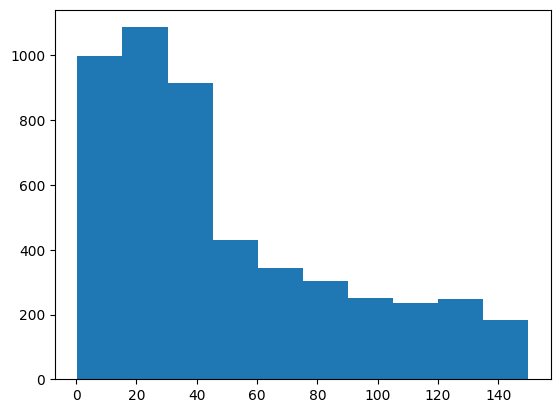

2958it [00:04, 623.14it/s]


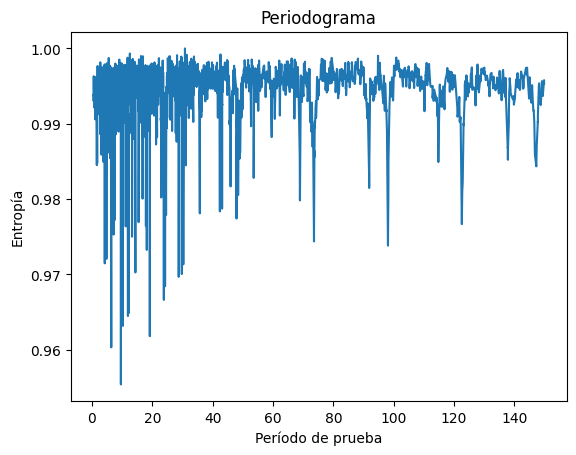

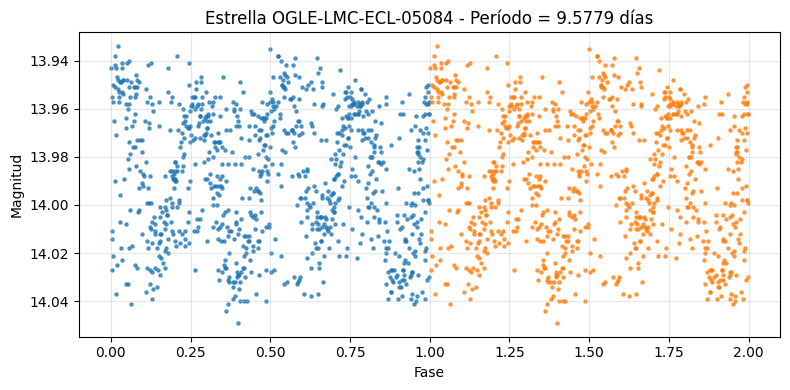

Procesando estrellas:  20%|██        | 1/5 [00:05<00:21,  5.46s/it]

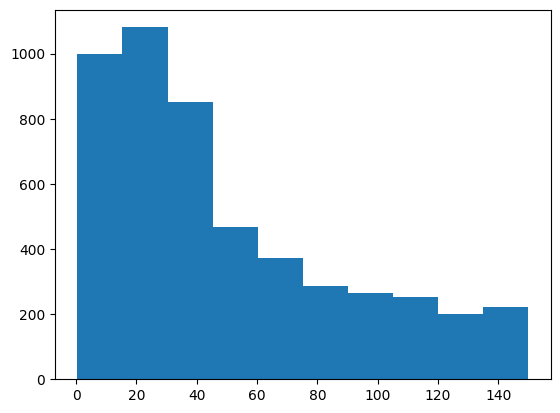

2999it [00:04, 646.33it/s]


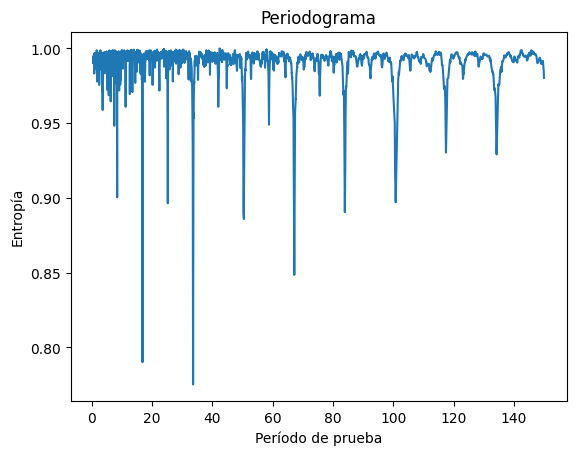

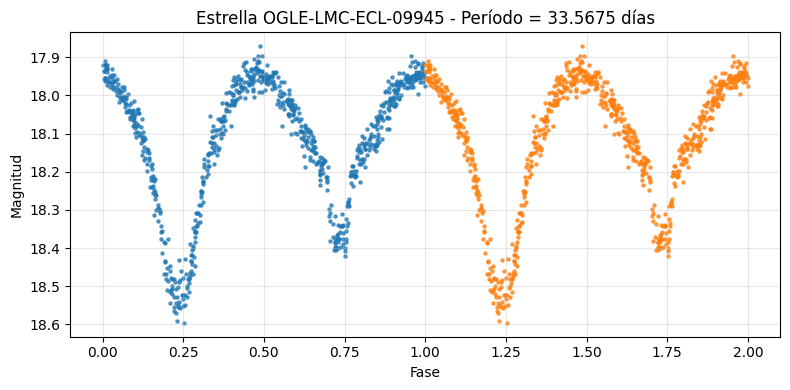

Procesando estrellas:  40%|████      | 2/5 [00:10<00:16,  5.37s/it]

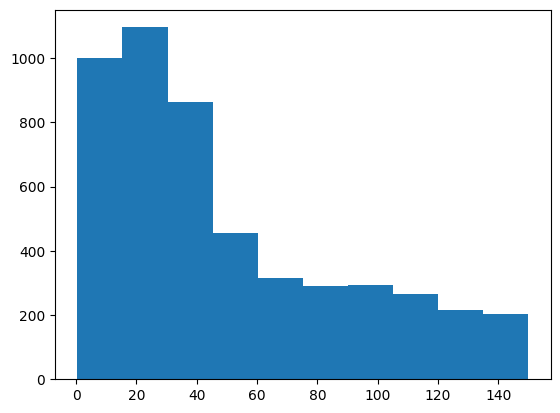

3000it [00:06, 450.83it/s]


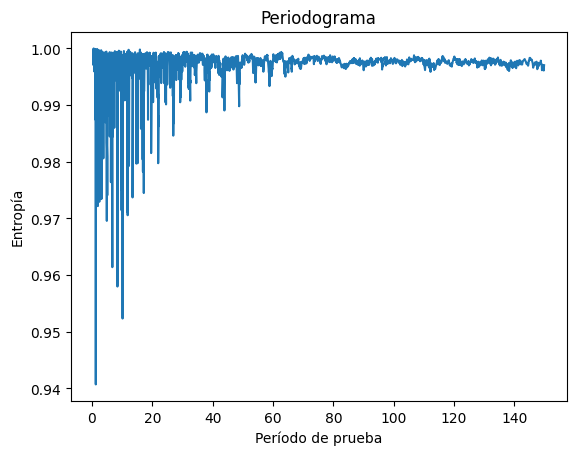

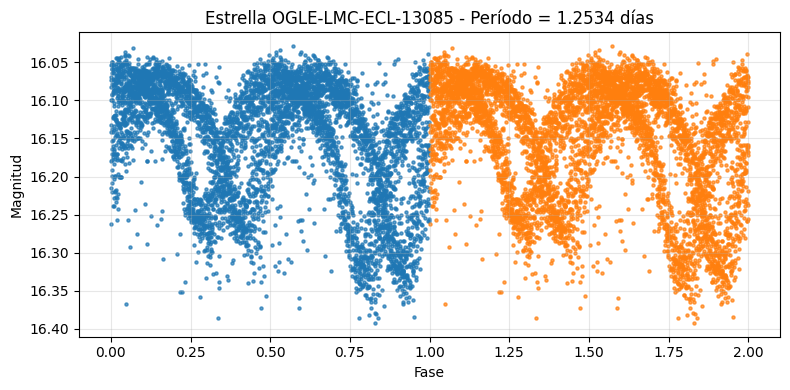

Procesando estrellas:  60%|██████    | 3/5 [00:18<00:12,  6.32s/it]

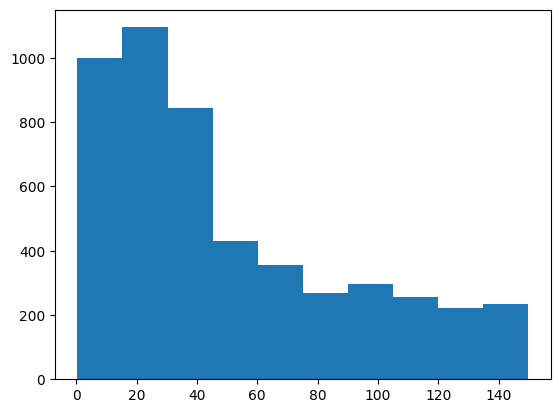

2977it [00:06, 452.00it/s]


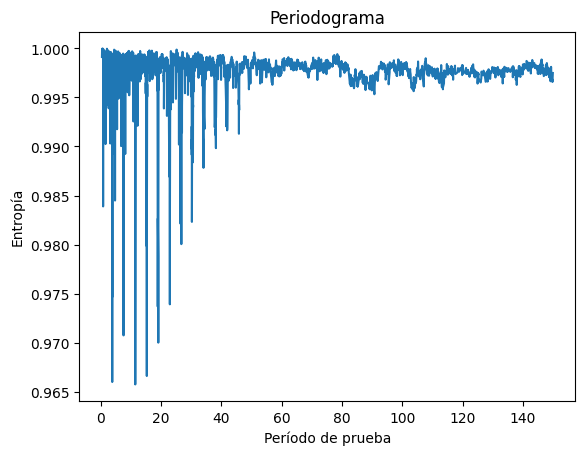

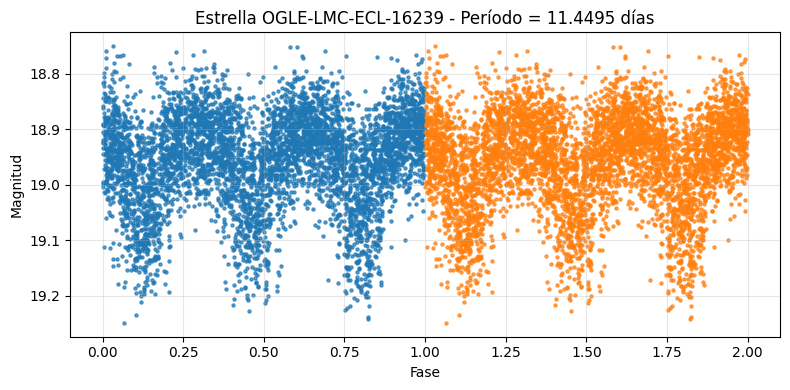

Procesando estrellas:  80%|████████  | 4/5 [00:25<00:06,  6.72s/it]

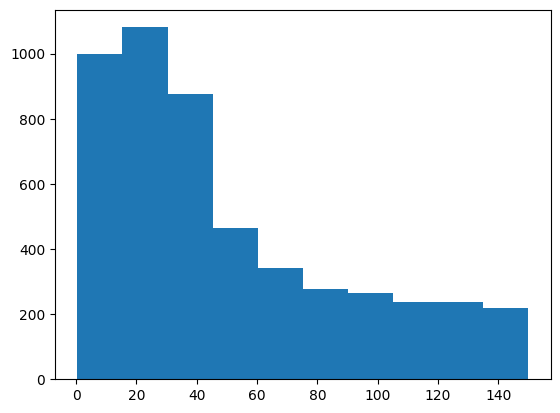

3027it [00:04, 633.06it/s]


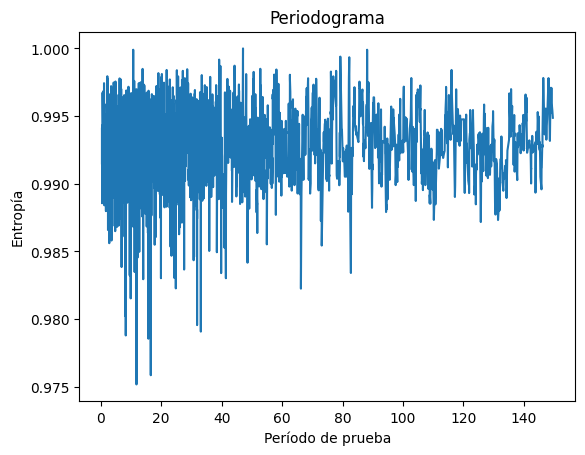

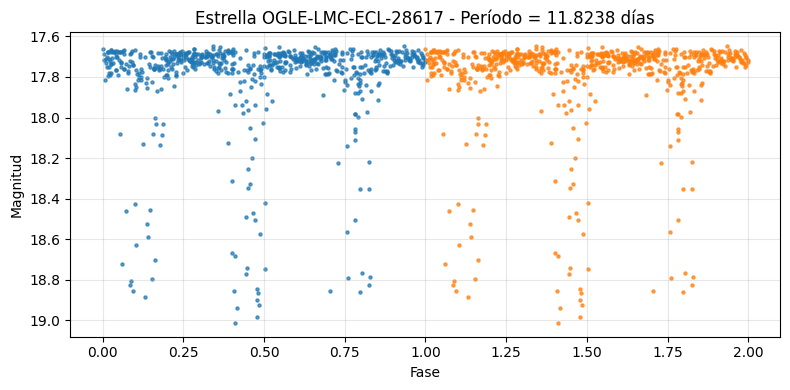

Procesando estrellas: 100%|██████████| 5/5 [00:31<00:00,  6.22s/it]


RESUMEN DE RESULTADOS
OGLE-LMC-ECL-05084: Período hallado = 9.577946 días, Período documentado = 2.693000 días, Entropía = 0.9554, Puntos = 912, Error absoluto = 6.8849, Error relativo: 2.5566
OGLE-LMC-ECL-09945: Período hallado = 33.567521 días, Período documentado = 33.580000 días, Entropía = 0.7752, Puntos = 787, Error absoluto = 0.0125, Error relativo: 0.0004
OGLE-LMC-ECL-13085: Período hallado = 1.253414 días, Período documentado = 1.253940 días, Entropía = 0.9407, Puntos = 5761, Error absoluto = 0.0005, Error relativo: 0.0004
OGLE-LMC-ECL-16239: Período hallado = 11.449469 días, Período documentado = 1.581350 días, Entropía = 0.9657, Puntos = 5602, Error absoluto = 9.8681, Error relativo: 6.2403
OGLE-LMC-ECL-28617: Período hallado = 11.823773 días, Período documentado = 2.670200 días, Entropía = 0.9752, Puntos = 678, Error absoluto = 9.1536, Error relativo: 3.4280

Resultados guardados en 'resultados_periodos.csv'


In [ ]:
# BINARIAS ECLIPSANTES
if __name__ == "__main__":
    # Procesar primeros 5 archivos
    resultados = procesar_archivos(
        carpeta="data/eclipsing",
        tipo="binary",
        p0=0.4,
        p1=150,
        p_num=5000,  
        plot_individual=True,  # Muestra cada curva de luz
        plot_s=True,
        x_parts=17,
        y_parts=5,
        plot_p=True
    )
    
    # Guardar resultados a CSV
    resultados.to_csv("resultados_periodos_rrlyrae.csv", index=False)
    print(f"\nResultados guardados en 'resultados_periodos.csv'")